In [1]:
import sys
import shap
# Training with numpy == 1.26.4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
# Training with tf == 25.02-tf2-py3
from tensorflow.keras.models import load_model
import pickle, gzip

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-06 07:37:34.836839: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 07:37:35.024075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-06 07:37:35.104186: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-06 07:37:35.131413: E external/l

In [2]:
ROOT_DIR = Path.cwd().parents[1]
sys.path.append(str(ROOT_DIR / "src" / "data_preprocessing"))
from normalize_fn import load
model_file    = ROOT_DIR / "src" / "model_training" / "checkpoints" / "final_model.h5"
features_file = ROOT_DIR / "datasets" / "Feature_vectors_dataset.p.gz"
results_dir   = ROOT_DIR / "src" / "shap" / "res_shap"
results_dir.mkdir(parents=True, exist_ok=True)

In [3]:
norm = 'norm'
model = load_model(str(model_file))
train_features, _, _, test_features, _, _, _, _ = load(norm=norm)

I0000 00:00:1772782658.002226     253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772782658.362564     253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772782658.362609     253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772782658.364854     253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772782658.364893     253 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

In [4]:
with gzip.open(features_file, 'rb') as f:
    features_df = pickle.load(f)
non_feature_cols = [c for c in ['Unnamed: 0', 'synergy', 'fold', 'drug_a_name', 'drug_b_name', 'cell_line']
                    if c in features_df.columns]
features_df = features_df.drop(columns=non_feature_cols)

In [5]:
labels_df   = pd.read_csv(ROOT_DIR / "datasets" / "labels.csv")
raw_train   = features_df.to_numpy(np.float32)
train_idx   = np.where((labels_df['fold'] != 0) & (labels_df['fold'] != 1))[0]
X_tr_raw    = raw_train[train_idx]
std1_raw    = np.nanstd(X_tr_raw, axis=0)
feat_filt   = std1_raw > 1e-8
feature_names = np.array(features_df.columns.tolist())[feat_filt]
print(f"Number of features after filtering: {len(feature_names)}")

Number of features after filtering: 7060


In [6]:
np.random.seed(42)
bg_idx      = np.random.choice(len(train_features), size=1000, replace=False)
background  = train_features[bg_idx].astype(np.float32)
test_sample = test_features.astype(np.float32)
print(f"Computing SHAP on full test set: {test_sample.shape[0]}")
explainer   = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(test_sample)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.array(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
print(f"SHAP values shape: {shap_values.shape}")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
std_abs_shap  = np.abs(shap_values).std(axis=0)
all_importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Mean_SHAP' : mean_abs_shap,
    'Std_SHAP'  : std_abs_shap,
    'Max_SHAP'  : np.abs(shap_values).max(axis=0),
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
print(f"\nTop 10 features:")
print(all_importance_df.head(10).to_string(index=False))

Computing SHAP on full test set: 4554


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+p

SHAP values shape: (4554, 7060)

Top 10 features:
         Feature  Mean_SHAP  Std_SHAP  Max_SHAP
          B_Qmin   0.033946  0.025945  0.271794
A_ECFP_ECFP6_127   0.032101  0.087036  1.231791
A_ECFP_ECFP6_295   0.032060  0.084878  1.251382
B_ECFP_ECFP6_767   0.031740  0.027173  0.225852
A_ECFP_ECFP6_267   0.031618  0.085623  1.220116
A_ECFP_ECFP6_377   0.031366  0.084914  1.218851
B_ECFP_ECFP6_435   0.031199  0.029953  0.299423
A_ECFP_ECFP6_702   0.028364  0.025626  0.254589
          A_nHBD   0.027573  0.021605  0.203178
A_ECFP_ECFP6_767   0.025894  0.023072  0.203365


In [7]:
with open(results_dir / "all_features_shap.txt", "w") as f:
    for i, row in all_importance_df.iterrows():
        f.write(f"Rank {i+1}: {row['Feature']}  Mean|SHAP|: {row['Mean_SHAP']:.6f}  Std: {row['Std_SHAP']:.6f}  Max: {row['Max_SHAP']:.6f}\n")

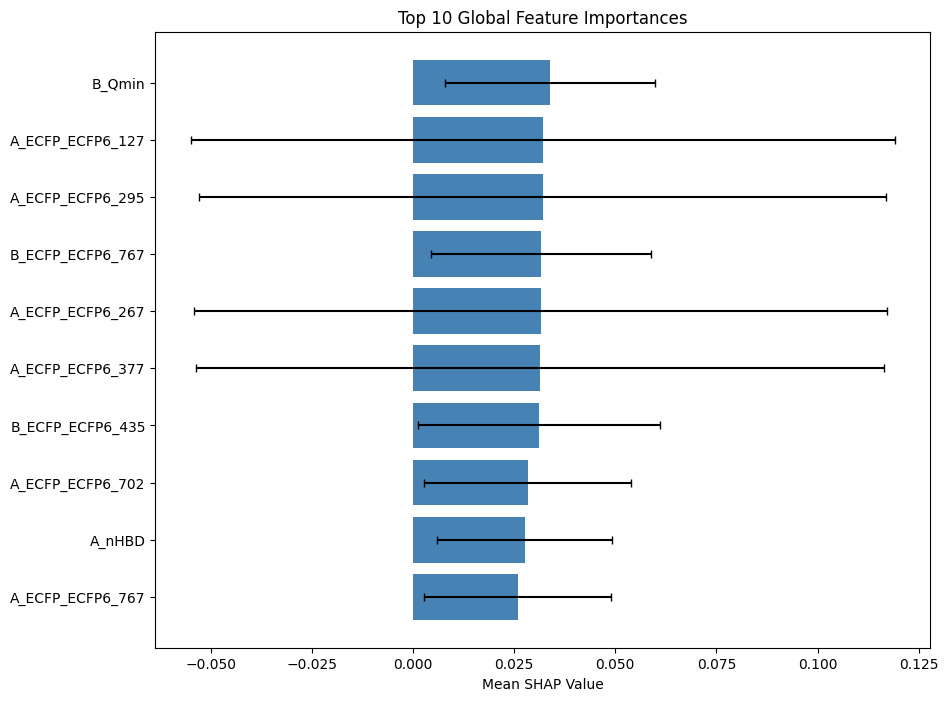

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
top10 = all_importance_df.head(10)
ax.barh(top10['Feature'][::-1], top10['Mean_SHAP'][::-1], color='steelblue', xerr=top10['Std_SHAP'][::-1], capsize=3)
ax.set_xlabel('Mean SHAP Value')
ax.set_title('Top 10 Global Feature Importances')
plt.savefig(results_dir / 'shap_top10_bar.png', dpi=150)
plt.show()

/tmp/ipykernel_253/2905102768.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


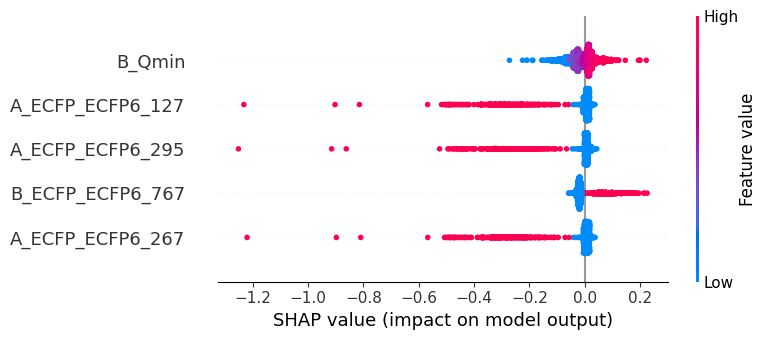

In [9]:
feature_names_list = feature_names.tolist()
top5_features = all_importance_df.head(5)['Feature'].tolist()
top5_idx = [feature_names_list.index(f) for f in top5_features]
shap.summary_plot(
    shap_values[:, top5_idx],
    test_sample[:, top5_idx],
    feature_names=top5_features,
    show=False)
plt.savefig(results_dir / 'shap_summary_plot.png', dpi=150)
plt.show()

In [10]:
#BEZ features
test_labels = labels_df[labels_df['fold'] == 0].reset_index(drop=True)
bez_b_idx   = test_labels[test_labels['drug_b_name'] == 'BEZ-235'].index.tolist()
bez_a_idx   = test_labels[test_labels['drug_a_name'] == 'BEZ-235'].index.tolist()
print(f"\nBEZ-235 as Drug A : {len(bez_a_idx)} samples")
print(f"BEZ-235 as Drug B: {len(bez_b_idx)} samples")


BEZ-235 as Drug A : 39 samples
BEZ-235 as Drug B: 195 samples


In [ ]:
feature_names_list = feature_names.tolist()
if len(bez_b_idx) > 0:
    bez_shap    = shap_values[bez_b_idx]
    b_feat_idx  = [i for i, f in enumerate(feature_names_list) if f.startswith('B_')]
    bez_b_names = [feature_names_list[i] for i in b_feat_idx]
    bez_b_df    = pd.DataFrame({
        'Feature'   : bez_b_names,
        'Mean_SHAP' : np.abs(bez_shap[:, b_feat_idx]).mean(axis=0)
    }).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
    print(f"BEZ-235 as Drug B - Top 10 features:")
    print(bez_b_df.head(10).to_string(index=False))
if len(bez_a_idx) > 0:
    bez_shap    = shap_values[bez_a_idx]
    a_feat_idx  = [i for i, f in enumerate(feature_names_list) if f.startswith('A_')]
    bez_a_names = [feature_names_list[i] for i in a_feat_idx]
    bez_a_df    = pd.DataFrame({
        'Feature'   : bez_a_names,
        'Mean_SHAP' : np.abs(bez_shap[:, a_feat_idx]).mean(axis=0)
    }).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
    print(f"BEZ-235 as Drug A - Top 10 features:")
    print(bez_a_df.head(10).to_string(index=False))

BEZ-235 as Drug B - Top 10 features:
         Feature  Mean_SHAP
B_ECFP_ECFP6_869   0.149203
 B_ECFP_ECFP6_58   0.146820
B_ECFP_ECFP6_517   0.143920
B_ECFP_ECFP6_177   0.140490
B_ECFP_ECFP6_785   0.138440
B_ECFP_ECFP6_476   0.136510
 B_ECFP_ECFP6_89   0.136460
B_ECFP_ECFP6_566   0.135715
B_ECFP_ECFP6_618   0.134970
B_ECFP_ECFP6_393   0.134866
BEZ-235 as Drug A - Top 10 features:
         Feature  Mean_SHAP
A_ECFP_ECFP6_330   0.368766
A_ECFP_ECFP6_555   0.351689
A_ECFP_ECFP6_566   0.345611
 A_ECFP_ECFP6_89   0.342992
A_ECFP_ECFP6_393   0.342892
 A_ECFP_ECFP6_31   0.339500
 A_ECFP_ECFP6_43   0.332846
A_ECFP_ECFP6_618   0.328413
    A_EstateVSA3   0.327540
A_ECFP_ECFP6_177   0.327238
